Step_size Array: [0.1, 0.5, 1, 1.5]


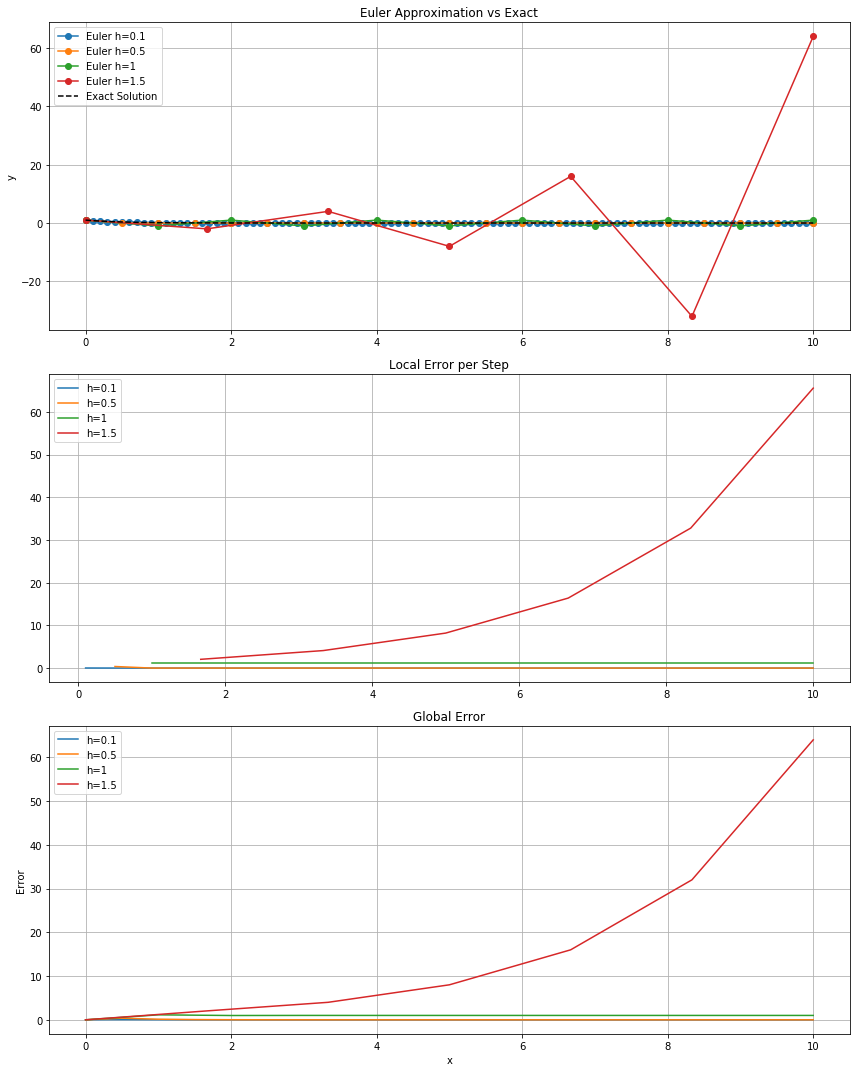

In [4]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
step_size= [0.1,0.5,1,1.5]
error_array=[]
h_array= []
print ("Step_size Array:", step_size)

first_x = None
first_y = None

def f(x,y):
    return -2*y

def exact_sol(x):
    return np.exp(-2*x)

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

for h in step_size: 
    x_start, x_end = 0, 10
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps +1)
    y_values = np.zeros(num_steps + 1)    
    y_values[0] = 1 
    local_error_per_step = []
 
    for i in range(num_steps):
        y_next_euler = y_values[i] + h * f(x_values[i], y_values[i])
        y_local_exact = y_values[i] * np.exp(-2 * h)
        local_error_per_step.append(np.abs(y_local_exact - y_next_euler))
        y_values[i + 1] = y_next_euler
        
  
    y_exact = exact_sol(x_values)
 
    global_error = np.abs(y_exact - y_values)
    

    error_array.append(np.max(global_error))
    h_array.append(h)
    
    axes[0].plot(x_values, y_values, marker='o', label=f"Euler h={h}")

    axes[1].plot(x_values[1:], local_error_per_step, label=f"h={h}")
    
    axes[2].plot(x_values, global_error, label=f"h={h}")

x_fine = np.linspace(0, 10, 500)

axes[0].plot(x_fine, exact_sol(x_fine), 'k--', label="Exact Solution")
axes[0].set_title("Euler Approximation vs Exact")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Local Error per Step")
axes[1].legend()
axes[1].grid(True)

axes[2].set_title("Global Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("Error")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()